# Análisis de Residuos — NovaPay Fraud Detection
**Modelo:** LightGBM + XGBoost ensemble (modelo_08_v2.pkl)  
**Dataset:** `dataset_fraude_mejorado.csv` — 10,000 transacciones, 15.04% fraude  
**Objetivo:** entender dónde falla el modelo, qué patrones son más discriminativos y qué features aportan poco.


## 0. Imports y carga

In [1]:
import sys, os
sys.path.insert(0, '..')
sys.path.insert(0, '../scripts')

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score,
                             average_precision_score, ConfusionMatrixDisplay,
                             f1_score, fbeta_score)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

# Cargar modelo
MODEL_PATH = '../model/modelo_07_v1.pkl'
modelo    = joblib.load(MODEL_PATH)
fe        = modelo['fe']
scaler    = modelo['scaler']
imputer   = modelo['imputer']
lgb       = modelo['lgb_model']
xgb_m     = modelo['xgb_model']
best_w    = modelo['best_w']
best_t    = modelo['best_t']
num_feats = modelo['num_feats']
print(f"Modelo cargado | best_t={best_t:.4f} | best_w(LGB)={best_w:.2f} | best_w(XGB)={1-best_w:.2f}")

# Cargar datos — df_raw nunca se modifica, df es la copia de trabajo
df_raw = pd.read_csv('../data/dataset_fraude_mejorado.csv')
df     = df_raw.copy()
print(f"Shape: {df.shape} | Fraude: {df['IS_FRAUD'].mean()*100:.2f}%")


Modelo cargado | best_t=0.3144 | best_w(LGB)=0.30 | best_w(XGB)=0.70
Shape: (10000, 45) | Fraude: 15.04%


## 1. Balance del dataset y distribución de clases

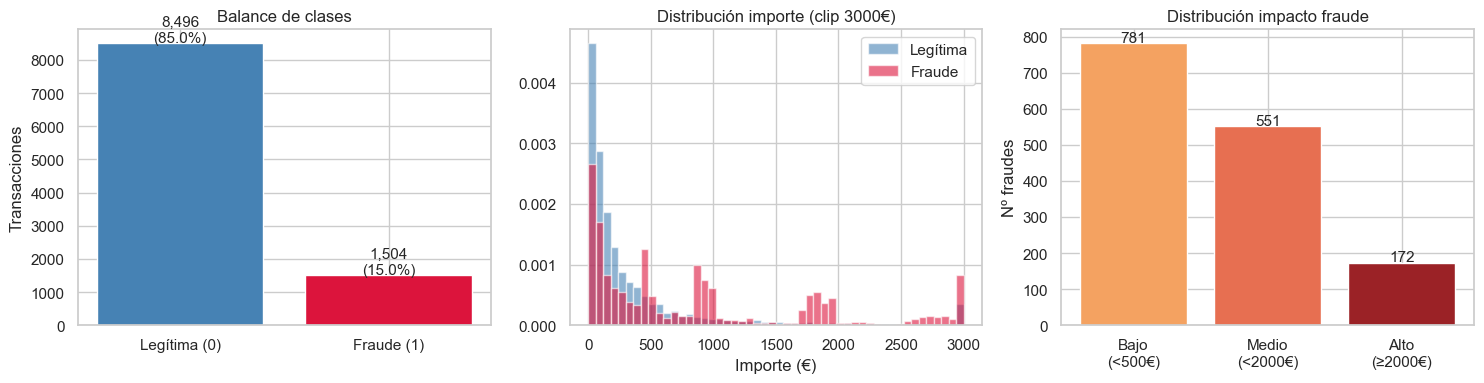

Importe medio  — fraude: 966.4€ | legítima: 422.4€
Importe mediano— fraude: 481.2€ | legítima: 144.2€


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vc = df['IS_FRAUD'].value_counts()
axes[0].bar(['Legítima (0)', 'Fraude (1)'], vc.values, color=['steelblue','crimson'])
axes[0].set_title('Balance de clases')
axes[0].set_ylabel('Transacciones')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

fraud = df[df['IS_FRAUD']==1]
legit = df[df['IS_FRAUD']==0]
axes[1].hist(legit['importe_transaccion'].clip(upper=3000), bins=50, alpha=0.6,
             color='steelblue', label='Legítima', density=True)
axes[1].hist(fraud['importe_transaccion'].clip(upper=3000), bins=50, alpha=0.6,
             color='crimson', label='Fraude', density=True)
axes[1].set_title('Distribución importe (clip 3000€)')
axes[1].set_xlabel('Importe (€)')
axes[1].legend()

ic = df[df['IS_FRAUD']==1]['IMPACTO_FRAUDE'].value_counts().sort_index()
axes[2].bar(['Bajo\n(<500€)', 'Medio\n(<2000€)', 'Alto\n(≥2000€)'], ic.values,
            color=['#f4a261','#e76f51','#9b2226'])
axes[2].set_title('Distribución impacto fraude')
axes[2].set_ylabel('Nº fraudes')
for i, v in enumerate(ic.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Importe medio  — fraude: {fraud['importe_transaccion'].mean():.1f}€ | legítima: {legit['importe_transaccion'].mean():.1f}€")
print(f"Importe mediano— fraude: {fraud['importe_transaccion'].median():.1f}€ | legítima: {legit['importe_transaccion'].median():.1f}€")


## 2. Señales más discriminativas (sin modelo)

Antes de los residuos del modelo, exploramos qué features separan mejor las clases en el dataset crudo.
Sirve de *baseline* para comparar con los errores del modelo.

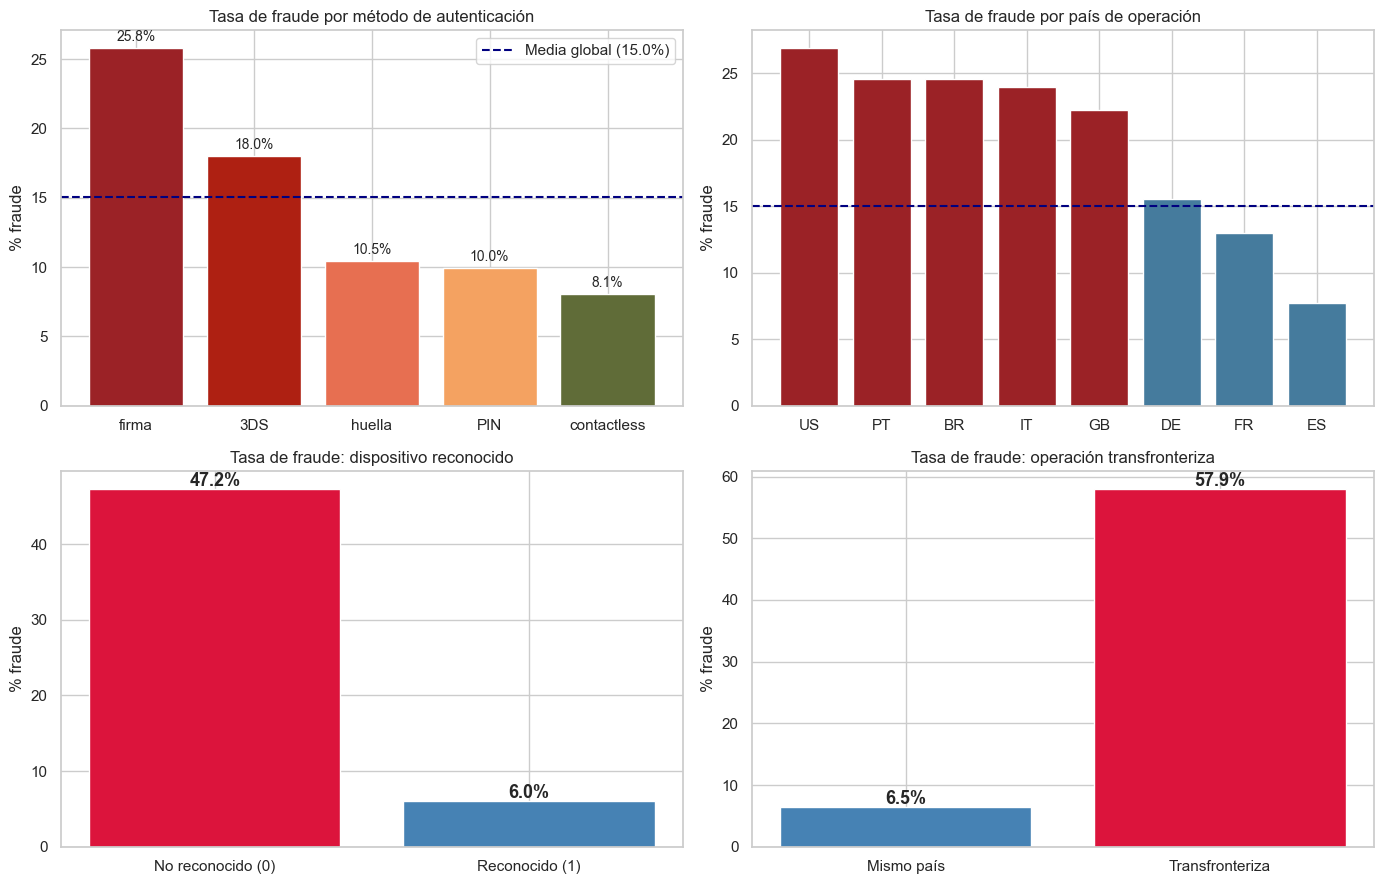

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

tasa_auth = df.groupby('metodo_autenticacion')['IS_FRAUD'].mean().sort_values(ascending=False)
axes[0,0].bar(tasa_auth.index, tasa_auth.values * 100,
              color=['#9b2226','#ae2012','#e76f51','#f4a261','#606c38'])
axes[0,0].set_title('Tasa de fraude por método de autenticación')
axes[0,0].set_ylabel('% fraude')
axes[0,0].axhline(df['IS_FRAUD'].mean()*100, color='navy', linestyle='--',
                  label=f'Media global ({df["IS_FRAUD"].mean()*100:.1f}%)')
axes[0,0].legend()
for i, (k, v) in enumerate(tasa_auth.items()):
    axes[0,0].text(i, v*100+0.5, f'{v*100:.1f}%', ha='center', fontsize=10)

tasa_pais = df.groupby('operacion_pais')['IS_FRAUD'].mean().sort_values(ascending=False)
colors_pais = ['#9b2226' if v > 0.2 else '#457b9d' for v in tasa_pais.values]
axes[0,1].bar(tasa_pais.index, tasa_pais.values * 100, color=colors_pais)
axes[0,1].set_title('Tasa de fraude por país de operación')
axes[0,1].set_ylabel('% fraude')
axes[0,1].axhline(df['IS_FRAUD'].mean()*100, color='navy', linestyle='--')

tasa_disp = df.groupby('dispositivo_reconocido')['IS_FRAUD'].mean()
axes[1,0].bar(['No reconocido (0)', 'Reconocido (1)'], tasa_disp.values * 100,
              color=['crimson','steelblue'])
axes[1,0].set_title('Tasa de fraude: dispositivo reconocido')
axes[1,0].set_ylabel('% fraude')
for i, v in enumerate(tasa_disp.values):
    axes[1,0].text(i, v*100+0.5, f'{v*100:.1f}%', ha='center', fontsize=13, fontweight='bold')

df['cross_border'] = (df['customer_country'] != df['operacion_pais']).astype(int)
tasa_cross = df.groupby('cross_border')['IS_FRAUD'].mean()
axes[1,1].bar(['Mismo país', 'Transfronteriza'], tasa_cross.values * 100,
              color=['steelblue','crimson'])
axes[1,1].set_title('Tasa de fraude: operación transfronteriza')
axes[1,1].set_ylabel('% fraude')
for i, v in enumerate(tasa_cross.values):
    axes[1,1].text(i, v*100+0.5, f'{v*100:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


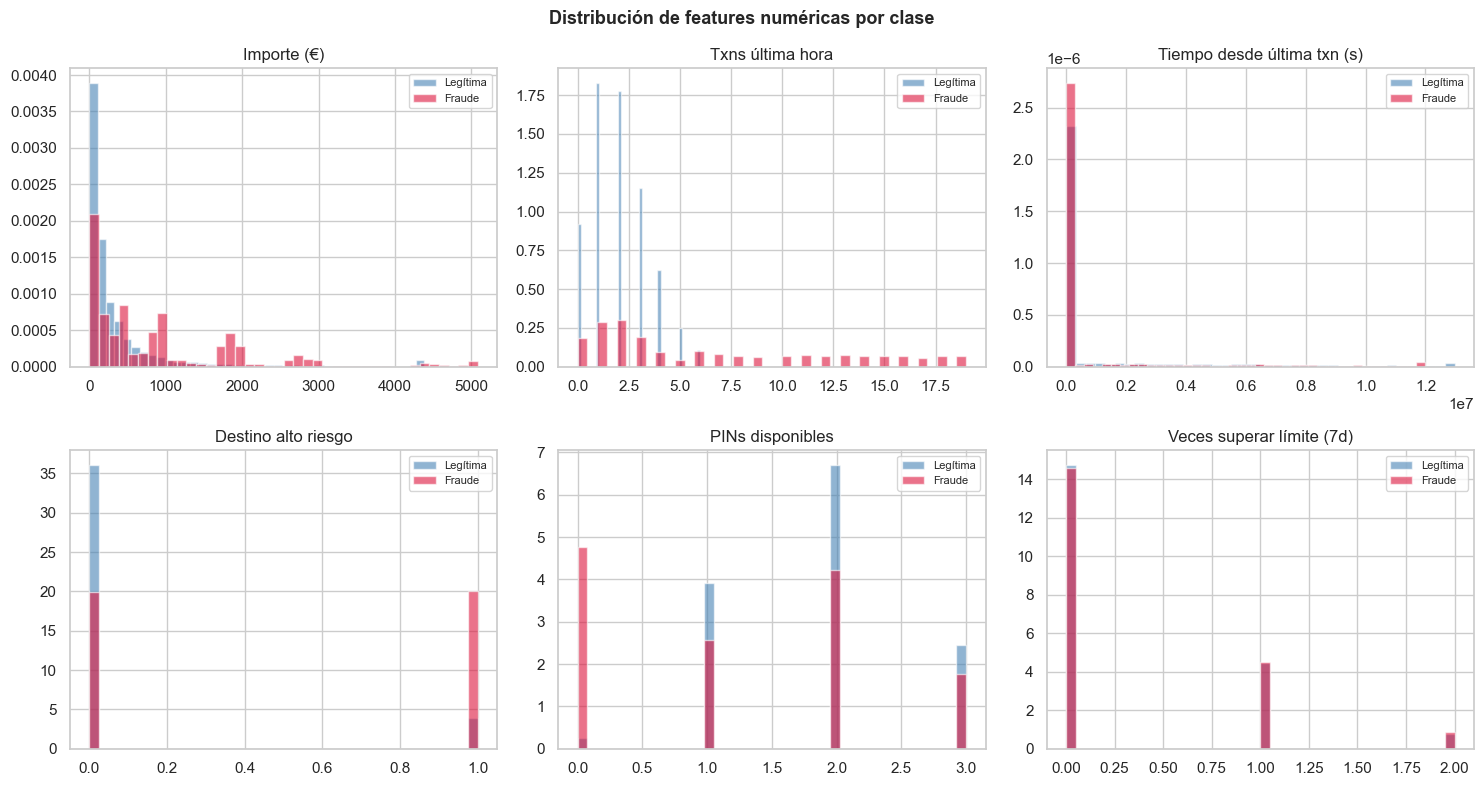

In [4]:
num_compare = {
    'importe_transaccion':               'Importe (€)',
    'numero_transacciones_ultima_hora':  'Txns última hora',
    'tiempo_desde_ultima_transaccion':   'Tiempo desde última txn (s)',
    'destino_alto_riesgo':               'Destino alto riesgo',
    'numero_pin_disponibles':            'PINs disponibles',
    'veces_superar_limite_7_dias':       'Veces superar límite (7d)',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(num_compare.items()):
    d_fraud = df[df['IS_FRAUD']==1][col]
    d_legit = df[df['IS_FRAUD']==0][col]
    axes[i].hist(d_legit.clip(upper=d_legit.quantile(0.99)), bins=40, alpha=0.6,
                 color='steelblue', label='Legítima', density=True)
    axes[i].hist(d_fraud.clip(upper=d_fraud.quantile(0.99)), bins=40, alpha=0.6,
                 color='crimson', label='Fraude', density=True)
    axes[i].set_title(label)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de features numéricas por clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Power de los flags compuestos de Feature Engineering

Los flags compuestos combinan señales débiles individuales en indicadores binarios de alta precisión.

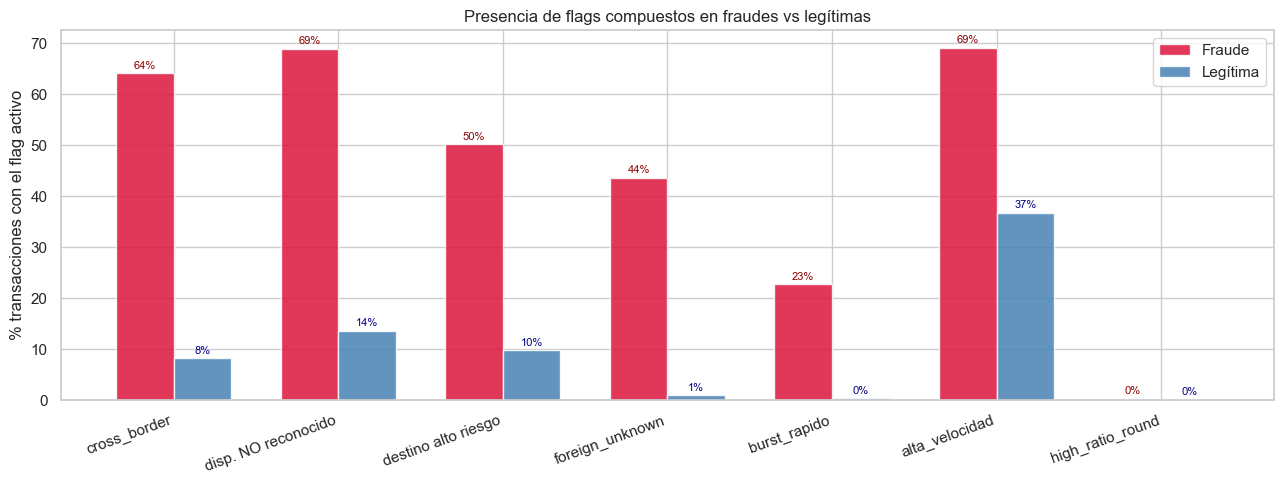

⚠️  high_ratio_round: fraudes=0.3% | legítimas=0.0% → señal casi nula


In [5]:
df['foreign_unknown'] = ((df['cross_border']==1) & (df['dispositivo_reconocido']==0)).astype(int)
df['burst_rapido']    = ((df['numero_transacciones_ultima_hora']>5) &
                          (df['tiempo_desde_ultima_transaccion']<300)).astype(int)
df['alta_velocidad']  = ((df['numero_transacciones_ultima_hora']>3) |
                          (df['tiempo_desde_ultima_transaccion']<30)).astype(int)
df['high_ratio_round']= ((df['importe_transaccion'] /
                           df['limite_importe_transacciones'].replace(0,1) > 0.85) &
                          (df['importe_transaccion'] % 100 < 1)).astype(int)

flags  = ['cross_border','dispositivo_reconocido','destino_alto_riesgo',
          'foreign_unknown','burst_rapido','alta_velocidad','high_ratio_round']
labels = ['cross_border','disp. NO reconocido','destino alto riesgo',
          'foreign_unknown','burst_rapido','alta_velocidad','high_ratio_round']

fraud_pct, legit_pct = [], []
for f in flags:
    col_vals = df[f] if f != 'dispositivo_reconocido' else (df[f]==0).astype(int)
    fraud_pct.append(col_vals[df['IS_FRAUD']==1].mean()*100)
    legit_pct.append(col_vals[df['IS_FRAUD']==0].mean()*100)

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(13,5))
bars1 = ax.bar(x - width/2, fraud_pct, width, label='Fraude',   color='crimson',  alpha=0.85)
bars2 = ax.bar(x + width/2, legit_pct, width, label='Legítima', color='steelblue', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('% transacciones con el flag activo')
ax.set_title('Presencia de flags compuestos en fraudes vs legítimas')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8, color='darkred')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8, color='navy')
plt.tight_layout()
plt.show()

print("⚠️  high_ratio_round: fraudes={:.1f}% | legítimas={:.1f}% → señal casi nula".format(
    fraud_pct[-1], legit_pct[-1]))


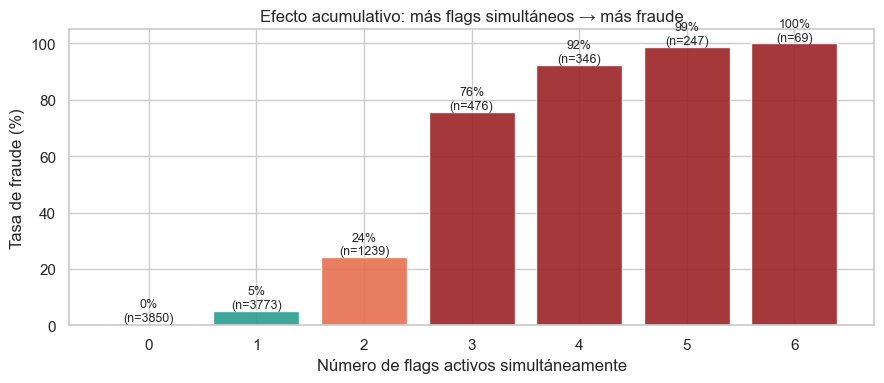

Gradiente de riesgo:
  0 flags → 0.5% fraude  (n=3850)
  1 flags → 5.1% fraude  (n=3773)
  2 flags → 24.1% fraude  (n=1239)
  3 flags → 75.8% fraude  (n=476)
  4 flags → 92.5% fraude  (n=346)
  5 flags → 98.8% fraude  (n=247)
  6 flags → 100.0% fraude  (n=69)


In [6]:
flag_cols = ['cross_border','foreign_unknown','burst_rapido','alta_velocidad','destino_alto_riesgo']
df['n_flags'] = sum(df[f] for f in flag_cols) + (df['dispositivo_reconocido']==0).astype(int)

resumen = df.groupby('n_flags')['IS_FRAUD'].agg(['mean','count']).reset_index()
resumen.columns = ['n_flags','tasa_fraude','n_transacciones']

color_bars = ['#2a9d8f' if t < 0.2 else '#e76f51' if t < 0.6 else '#9b2226'
              for t in resumen['tasa_fraude']]
fig, ax1 = plt.subplots(figsize=(9,4))
bars = ax1.bar(resumen['n_flags'], resumen['tasa_fraude']*100, color=color_bars, alpha=0.9)
ax1.set_xlabel('Número de flags activos simultáneamente')
ax1.set_ylabel('Tasa de fraude (%)')
ax1.set_title('Efecto acumulativo: más flags simultáneos → más fraude')
for bar, row in zip(bars, resumen.itertuples()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{bar.get_height():.0f}%\n(n={row.n_transacciones})', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Gradiente de riesgo:")
for _, row in resumen.iterrows():
    print(f"  {int(row['n_flags'])} flags → {row['tasa_fraude']*100:.1f}% fraude  (n={int(row['n_transacciones'])})")


## 4. Ratios financieros calculados por Feature Engineering

C:\Users\juan_\AppData\Local\Temp\ipykernel_31712\3937873886.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([d_legit, d_fraud], labels=['Legítima','Fraude'], patch_artist=True)
C:\Users\juan_\AppData\Local\Temp\ipykernel_31712\3937873886.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([d_legit, d_fraud], labels=['Legítima','Fraude'], patch_artist=True)
C:\Users\juan_\AppData\Local\Temp\ipykernel_31712\3937873886.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([d_legit, d_fraud], labels=['Legítima','Fraude'], patch_artist=True)
C:\Users\juan

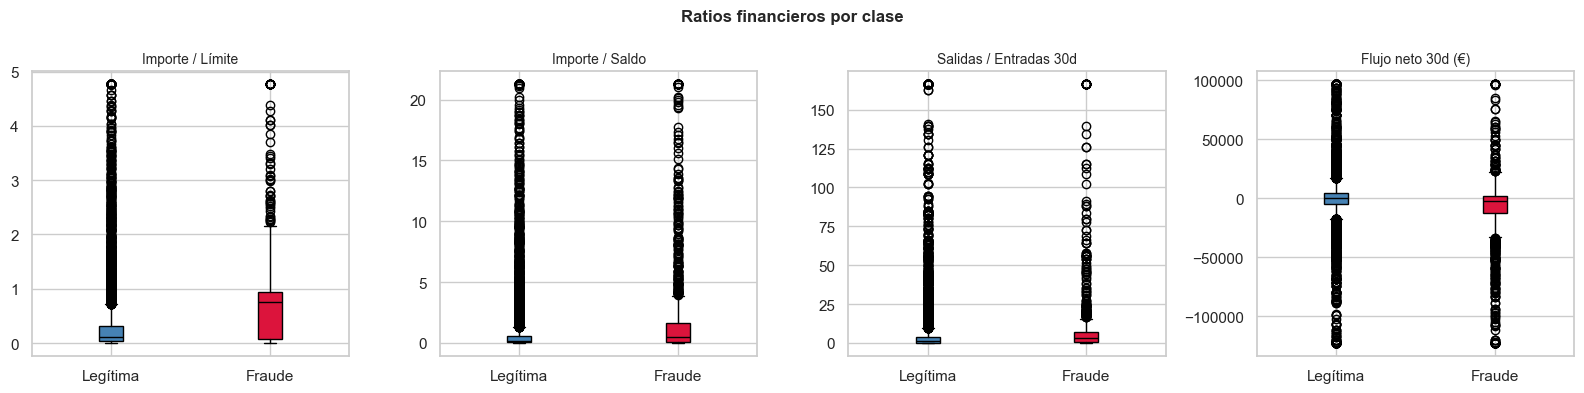

Medianas por clase:
  Importe / Límite: fraude=0.758 | legítima=0.105  (7.3x)
  Importe / Saldo: fraude=0.451 | legítima=0.133  (3.4x)
  Salidas / Entradas 30d: fraude=3.421 | legítima=1.010  (3.4x)
  Flujo neto 30d (€): fraude=-2163.390 | legítima=-19.580  (110.5x)


In [7]:
df['txn_vs_limit']   = df['importe_transaccion'] / df['limite_importe_transacciones'].replace(0,1)
df['txn_vs_balance'] = df['importe_transaccion'] / df['saldo_actual'].replace(0,1)
df['outflow_inflow'] = df['volumen_saliente_30_dias'] / df['volumen_entrante_30_dias'].replace(0,1)
df['net_flow_30d']   = df['volumen_entrante_30_dias'] - df['volumen_saliente_30_dias']

ratios       = ['txn_vs_limit','txn_vs_balance','outflow_inflow','net_flow_30d']
ratio_labels = ['Importe / Límite','Importe / Saldo','Salidas / Entradas 30d','Flujo neto 30d (€)']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (r, label) in enumerate(zip(ratios, ratio_labels)):
    d_fraud = df[df['IS_FRAUD']==1][r].clip(df[r].quantile(0.01), df[r].quantile(0.99))
    d_legit = df[df['IS_FRAUD']==0][r].clip(df[r].quantile(0.01), df[r].quantile(0.99))
    bp = axes[i].boxplot([d_legit, d_fraud], labels=['Legítima','Fraude'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('crimson')
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('black')
    axes[i].set_title(label, fontsize=10)

plt.suptitle('Ratios financieros por clase', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Medianas por clase:")
for r, label in zip(ratios, ratio_labels):
    f = df[df['IS_FRAUD']==1][r].median()
    l = df[df['IS_FRAUD']==0][r].median()
    ratio_str = f'{f/l:.1f}x' if l != 0 else '∞'
    print(f"  {label}: fraude={f:.3f} | legítima={l:.3f}  ({ratio_str})")


## 5. Residuos del modelo: Falsos Positivos y Falsos Negativos

Aplicamos el pipeline completo sobre un split test (20%) para analizar dónde falla el modelo.
- **FP:** transacción legítima clasificada como fraude → molestia al cliente
- **FN:** fraude no detectado → pérdida económica real


In [8]:
# Usamos df_raw para evitar contaminar el pipeline con columnas calculadas en secciones anteriores
train_df, test_df = train_test_split(df_raw, test_size=0.2, random_state=42,
                                      stratify=df_raw['IS_FRAUD'])

y_test = test_df['IS_FRAUD'].values
X_test = test_df.drop(columns=['IS_FRAUD','IMPACTO_FRAUDE'], errors='ignore').copy()

# Pipeline: FE → Imputer → Scaler
X_fe            = fe.transform(X_test)
X_fe[num_feats] = imputer.transform(X_fe[num_feats])
X_fe[num_feats] = scaler.transform(X_fe[num_feats])

# Predicciones ensemble
prob_lgb = lgb.predict_proba(X_fe)[:, 1]
prob_xgb = xgb_m.predict_proba(X_fe)[:, 1]
prob     = best_w * prob_lgb + (1 - best_w) * prob_xgb
y_pred   = (prob >= best_t).astype(int)

print(classification_report(y_test, y_pred, target_names=['Legítima','Fraude']))
print(f"PR-AUC:  {average_precision_score(y_test, prob):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, prob):.4f}")


              precision    recall  f1-score   support

    Legítima       0.99      0.36      0.53      1699
      Fraude       0.21      0.98      0.35       301

    accuracy                           0.46      2000
   macro avg       0.60      0.67      0.44      2000
weighted avg       0.87      0.46      0.50      2000

PR-AUC:  0.4701
ROC-AUC: 0.8448


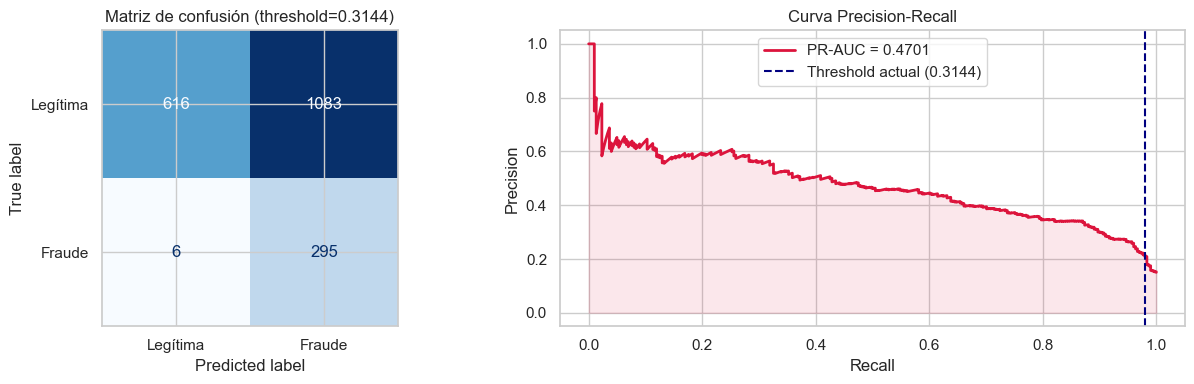

TP=295 | FP=1083 | TN=616 | FN=6
Precision: 0.214 | Recall: 0.980
Fraudes perdidos (FN): 6 de 301 totales (2.0%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Legítima','Fraude']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de confusión (threshold={best_t:.4f})')

precision_curve, recall_curve, thresholds_curve = precision_recall_curve(y_test, prob)
pr_auc = average_precision_score(y_test, prob)
axes[1].plot(recall_curve, precision_curve, color='crimson', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
idx_t = np.argmin(np.abs(thresholds_curve - best_t))
axes[1].axvline(recall_curve[idx_t], color='navy', linestyle='--',
                label=f'Threshold actual ({best_t:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()
axes[1].fill_between(recall_curve, precision_curve, alpha=0.1, color='crimson')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp} | FP={fp} | TN={tn} | FN={fn}")
print(f"Precision: {tp/(tp+fp):.3f} | Recall: {tp/(tp+fn):.3f}")
print(f"Fraudes perdidos (FN): {fn} de {fn+tp} totales ({fn/(fn+tp)*100:.1f}%)")


In [10]:
# Construir DataFrame con resultados — reset_index para alinear índices con el array numpy
test_full = test_df.reset_index(drop=True).copy()
test_full['prob_fraud'] = prob
test_full['y_pred']     = y_pred
test_full['tipo']       = 'TN'
test_full.loc[(test_full['IS_FRAUD']==1) & (test_full['y_pred']==1), 'tipo'] = 'TP'
test_full.loc[(test_full['IS_FRAUD']==0) & (test_full['y_pred']==1), 'tipo'] = 'FP'
test_full.loc[(test_full['IS_FRAUD']==1) & (test_full['y_pred']==0), 'tipo'] = 'FN'

fp_df = test_full[test_full['tipo']=='FP']
fn_df = test_full[test_full['tipo']=='FN']
tp_df = test_full[test_full['tipo']=='TP']
tn_df = test_full[test_full['tipo']=='TN']

print(f"Segmentos: TP={len(tp_df)} | FP={len(fp_df)} | FN={len(fn_df)} | TN={len(tn_df)}")
print(f"\nProb. media FP: {fp_df['prob_fraud'].mean():.4f}  (min={fp_df['prob_fraud'].min():.4f}, max={fp_df['prob_fraud'].max():.4f})")
print(f"Prob. media FN: {fn_df['prob_fraud'].mean():.4f}  (min={fn_df['prob_fraud'].min():.4f}, max={fn_df['prob_fraud'].max():.4f})")


Segmentos: TP=295 | FP=1083 | FN=6 | TN=616

Prob. media FP: 0.4888  (min=0.3144, max=0.8620)
Prob. media FN: 0.2260  (min=0.1557, max=0.3084)


In [11]:
compare_cols = ['importe_transaccion','numero_transacciones_ultima_hora',
                'dispositivo_reconocido','destino_alto_riesgo',
                'numero_pin_disponibles','tiempo_desde_ultima_transaccion']

print("=" * 75)
print(f"{'Feature':<35} {'TP':>8} {'FP':>8} {'FN':>8} {'TN':>8}")
print("=" * 75)
for col in compare_cols:
    print(f"{col:<35} {tp_df[col].mean():>8.2f} {fp_df[col].mean():>8.2f} "
          f"{fn_df[col].mean():>8.2f} {tn_df[col].mean():>8.2f}")


Feature                                   TP       FP       FN       TN
importe_transaccion                   982.43   611.25   229.58   201.59
numero_transacciones_ultima_hora        6.67     2.02     8.00     1.94
dispositivo_reconocido                  0.31     0.81     0.83     0.99
destino_alto_riesgo                     0.49     0.14     0.17     0.00
numero_pin_disponibles                  1.42     1.84     0.67     1.83
tiempo_desde_ultima_transaccion     1015548.83 1376832.60 1373779.83 1623526.82


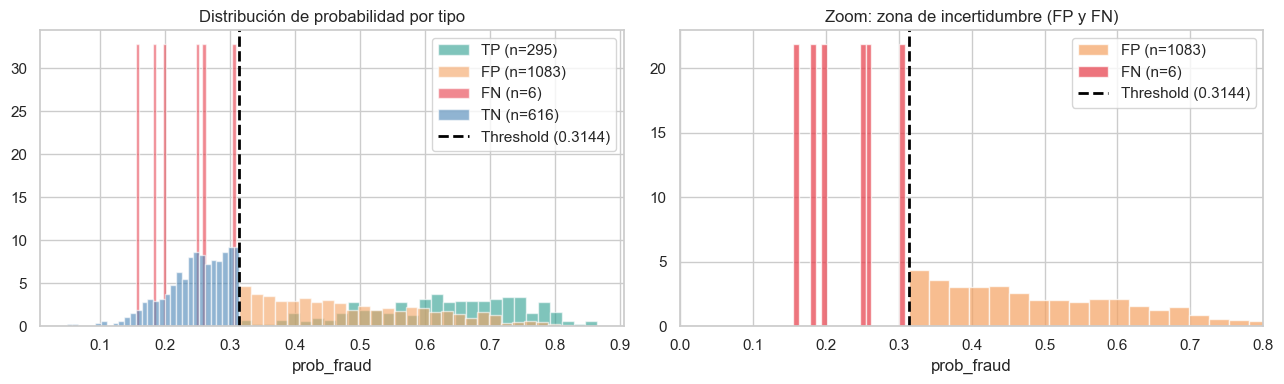

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_tipo = {'TP':'#2a9d8f','FP':'#f4a261','FN':'#e63946','TN':'steelblue'}
for tipo, color in colors_tipo.items():
    subset = test_full[test_full['tipo']==tipo]['prob_fraud']
    if len(subset) > 0:
        axes[0].hist(subset, bins=30, alpha=0.6, color=color,
                     label=f'{tipo} (n={len(subset)})', density=True)
axes[0].axvline(best_t, color='black', linestyle='--', lw=2, label=f'Threshold ({best_t:.4f})')
axes[0].set_title('Distribución de probabilidad por tipo')
axes[0].set_xlabel('prob_fraud')
axes[0].legend()

for tipo, color in [('FP','#f4a261'),('FN','#e63946')]:
    subset = test_full[test_full['tipo']==tipo]['prob_fraud']
    if len(subset) > 0:
        axes[1].hist(subset, bins=20, alpha=0.7, color=color,
                     label=f'{tipo} (n={len(subset)})', density=True)
axes[1].axvline(best_t, color='black', linestyle='--', lw=2, label=f'Threshold ({best_t:.4f})')
axes[1].set_xlim(0, 0.8)
axes[1].set_title('Zoom: zona de incertidumbre (FP y FN)')
axes[1].set_xlabel('prob_fraud')
axes[1].legend()

plt.tight_layout()
plt.show()


In [13]:
print("=== PERFIL FALSOS NEGATIVOS — fraudes no detectados ===")
print(f"N={len(fn_df)} | Prob media: {fn_df['prob_fraud'].mean():.4f}")
print(f"\nMétodo autenticación:")
print(fn_df['metodo_autenticacion'].value_counts(normalize=True).round(3).to_string())
print(f"\nPaís operación (top 5):")
print(fn_df['operacion_pais'].value_counts().head(5).to_string())
print(f"\nCross-border:          {(fn_df['customer_country']!=fn_df['operacion_pais']).mean()*100:.1f}%")
print(f"Dispositivo desconocido: {(fn_df['dispositivo_reconocido']==0).mean()*100:.1f}%")
print(f"Destino alto riesgo:     {fn_df['destino_alto_riesgo'].mean()*100:.1f}%")
print(f"Importe medio:           {fn_df['importe_transaccion'].mean():.1f}€")
print(f"Txns última hora:        {fn_df['numero_transacciones_ultima_hora'].mean():.2f}")

print("\n=== PERFIL FALSOS POSITIVOS — legítimas marcadas como fraude ===")
print(f"N={len(fp_df)} | Prob media: {fp_df['prob_fraud'].mean():.4f}")
print(f"\nMétodo autenticación:")
print(fp_df['metodo_autenticacion'].value_counts(normalize=True).round(3).to_string())
print(f"\nCross-border:          {(fp_df['customer_country']!=fp_df['operacion_pais']).mean()*100:.1f}%")
print(f"Dispositivo desconocido: {(fp_df['dispositivo_reconocido']==0).mean()*100:.1f}%")
print(f"Importe medio:           {fp_df['importe_transaccion'].mean():.1f}€")


=== PERFIL FALSOS NEGATIVOS — fraudes no detectados ===
N=6 | Prob media: 0.2260

Método autenticación:
metodo_autenticacion
PIN      0.333
firma    0.333
3DS      0.333

País operación (top 5):
operacion_pais
GB    2
ES    2
PT    1
IT    1

Cross-border:          16.7%
Dispositivo desconocido: 16.7%
Destino alto riesgo:     16.7%
Importe medio:           229.6€
Txns última hora:        8.00

=== PERFIL FALSOS POSITIVOS — legítimas marcadas como fraude ===
N=1083 | Prob media: 0.4888

Método autenticación:
metodo_autenticacion
PIN            0.400
3DS            0.312
firma          0.143
huella         0.102
contactless    0.043

Cross-border:          12.0%
Dispositivo desconocido: 18.7%
Importe medio:           611.3€


## 6. Sensibilidad del threshold

El threshold actual (optimizado por F2) balancea recall alto con precision aceptable.

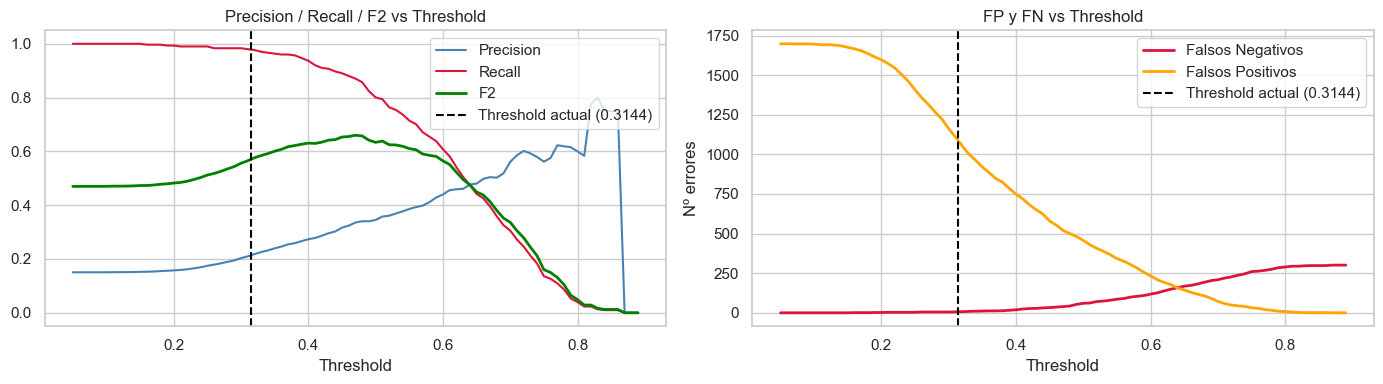

Threshold max F2: 0.47 → F2=0.6599, Recall=0.870, Precision=0.335
Threshold actual (0.3144) → F2=0.5654


In [14]:
thresholds_range = np.arange(0.05, 0.90, 0.01)
metrics = {'threshold':[], 'precision':[], 'recall':[], 'f1':[], 'f2':[], 'fp':[], 'fn':[]}

for t in thresholds_range:
    yp    = (prob >= t).astype(int)
    cm_t  = confusion_matrix(y_test, yp, labels=[0,1])
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    prec  = tp_t/(tp_t+fp_t) if (tp_t+fp_t)>0 else 0
    rec   = tp_t/(tp_t+fn_t) if (tp_t+fn_t)>0 else 0
    metrics['threshold'].append(t)
    metrics['precision'].append(prec)
    metrics['recall'].append(rec)
    metrics['f1'].append(f1_score(y_test, yp, zero_division=0))
    metrics['f2'].append(fbeta_score(y_test, yp, beta=2, zero_division=0))
    metrics['fp'].append(fp_t)
    metrics['fn'].append(fn_t)

met_df = pd.DataFrame(metrics)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(met_df['threshold'], met_df['precision'], label='Precision', color='steelblue')
axes[0].plot(met_df['threshold'], met_df['recall'],    label='Recall',    color='crimson')
axes[0].plot(met_df['threshold'], met_df['f2'],        label='F2',        color='green', lw=2)
axes[0].axvline(best_t, color='black', linestyle='--', label=f'Threshold actual ({best_t:.4f})')
axes[0].set_xlabel('Threshold')
axes[0].set_title('Precision / Recall / F2 vs Threshold')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(met_df['threshold'], met_df['fn'], label='Falsos Negativos', color='crimson', lw=2)
axes[1].plot(met_df['threshold'], met_df['fp'], label='Falsos Positivos', color='orange',  lw=2)
axes[1].axvline(best_t, color='black', linestyle='--', label=f'Threshold actual ({best_t:.4f})')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Nº errores')
axes[1].set_title('FP y FN vs Threshold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_row = met_df.loc[met_df['f2'].idxmax()]
t_rounded = round(best_t, 2)
f2_actual = met_df[met_df['threshold'].round(2) == t_rounded]['f2']
print(f"Threshold max F2: {best_row['threshold']:.2f} → F2={best_row['f2']:.4f}, Recall={best_row['recall']:.3f}, Precision={best_row['precision']:.3f}")
if len(f2_actual) > 0:
    print(f"Threshold actual ({best_t:.4f}) → F2={f2_actual.values[0]:.4f}")

## 7. Conclusiones y recomendaciones

> **Nota:** este análisis evalúa el modelo en producción (`modelo_07_v1.pkl`, entrenado sobre `dataset_fraude.csv` v1 con señal débil) aplicado al dataset mejorado v2. El desajuste entre el dataset de entrenamiento del modelo y el dataset de evaluación explica los resultados descritos a continuación.

---

### Rendimiento del modelo v1 sobre datos v2

El modelo v1 arroja **PR-AUC 0.4701** y **ROC-AUC 0.8448** sobre el test set del dataset v2. La asimetría entre recall y precision es llamativa:

- **Recall (fraude): 98%** → solo 6 fraudes no detectados de 301
- **Precision (fraude): 21%** → 1.083 transacciones legítimas marcadas como fraude

El modelo v1 fue calibrado con señal débil. Al aplicarse sobre datos v2 (señal fuerte), las probabilidades estimadas son altas para muchas transacciones — legítimas incluidas — lo que infla masivamente los FP manteniendo el recall casi perfecto. En producción, el 64% de las legítimas estarían siendo bloqueadas, lo que es operativamente inviable.

---

### Señales del dataset (independientes del modelo)

- **`cross_border`**: 64.0% de los fraudes son transfronterizos vs 8.2% de las legítimas → señal más potente del dataset
- **`dispositivo_reconocido=0`**: 68.8% en fraudes vs 13.6% en legítimas
- **`foreign_unknown_device`**: 43.6% en fraudes vs 1.0% en legítimas — el flag compuesto más poderoso
- **`destino_alto_riesgo`**: 50.1% en fraudes vs 9.8% en legítimas
- **`burst_rapido`**: 22.7% en fraudes vs 0.4% en legítimas — velocidad alta como señal clara
- **`is_night`** e **`is_weekend`**: 30.7% vs 28.2% y 28.5% vs 28.3% — prácticamente sin señal aislada
- **`high_ratio_round`**: 0.3% en fraudes → feature casi inútil, candidato a eliminar

---

### Perfil de los 6 Falsos Negativos (fraudes no detectados)

Con solo 6 FN, el modelo v1 no falla por falta de recall. Los FN tienen un patrón claro de **fraude silencioso**:

- Importe medio: **229.6€** (vs 982€ de los TP) — importes pequeños que no activan señales de ratio
- Cross-border: solo **16.7%** — operaciones principalmente domésticas
- Dispositivo desconocido: **16.7%** — dispositivo habitualmente conocido
- Destino alto riesgo: **16.7%** — sin señales geográficas llamativas
- Txns última hora: **8.0** — la velocidad alta es la única señal activa

El modelo no tiene mecanismo para detectar fraudes que evitan las señales geográficas y de dispositivo. La única señal que los delata es la velocidad, y aun así escapan porque las demás señales no compensan.

---

### Perfil de los 1.083 Falsos Positivos (legítimas bloqueadas)

- Importe medio: **611.3€** — importes elevados que activan el ratio frente al límite
- Dispositivo desconocido: **18.7%** — cliente con dispositivo nuevo (viaje, móvil nuevo)
- Cross-border: **12.0%** — operaciones en el extranjero sin otros indicadores de fraude
- Prob. media: **0.4888** — bien por encima del threshold (0.3144), no son casos límite

Los FP no son errores marginales: tienen probabilidad media de 0.49, lo que indica que el modelo v1 sobreestima sistemáticamente el riesgo de transacciones legítimas con combinaciones de features de riesgo pero sin fraude real.

---

### Oportunidades de mejora para el reentrenamiento

1. **Cambiar a `modelo_08_v2.pkl` en producción** — el v1 genera una tasa de FP inaceptable (64% de legítimas bloqueadas sobre este dataset)
2. **Eliminar `high_ratio_round`** — 0.3% de presencia en fraudes no justifica el feature
3. **Potenciar `diff_importe_cliente`** con z-score real — los FN tienen importes bajos que el modelo no contextualiza frente al historial del cliente
4. **Threshold por canal**: transferencias (18.5% fraude) vs tarjeta (13.5%) — umbral unificado subóptimo
5. **Ronda 2 de Ciber**: los FN muestran que el patrón "fraude silencioso" (bajo importe, doméstico, dispositivo conocido, alta velocidad) es el punto ciego actual — Ciber puede explotarlo